# Mesh — Feedforward Depth vs Splat Renders, then Semantic Query

Fuses the same scene into a TSDF mesh from two depth sources and compares them:

- **feedforward** — the model's own depth maps in `pointcloud.zarr` (`mesh.source: feedforward`, the
  pipeline default, and what `02_pointcloud/feedforward_mesh.ipynb` does).
- **splats** — depth rendered from the trained Gaussian splat in `splats.zarr`, with the render alpha as
  confidence (`mesh.source: splats`). Requires `03_splats/train_splats.ipynb` first.

Both go through `mesh_from_tsdf_inputs`, the shared tail of the two adapters. The second half of the notebook
replaces the old `Splatter.query_mesh`: lifted MaskCLIP features are transferred onto the mesh vertices,
scored against a text query, and the best-matching connected region is saved as its own mesh.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
from pathlib import Path

import numpy as np
import torch
import zarr
from zarr.codecs import BloscCodec
import open3d as o3d
import pyvista as pv
from PIL import Image
from tqdm.auto import tqdm
import matplotlib

matplotlib.use("Agg") if os.environ.get("PYVISTA_OFF_SCREEN") else None
%matplotlib inline

%run ../notebook_utils.py
set_notebook_backend()

from collab_splats.pointcloud.feedforward.base import FeedforwardResult
from collab_splats.pointcloud.utils import lift_features
from collab_splats.preproc import FrameStore
from collab_splats.mesh.utils import (
    _splats_to_tsdf_inputs,
    features2vertex,
    mesh_clustering,
    mesh_from_tsdf_inputs,
    pointcloud_to_mesh,
)
from collab_splats.semantics.features import BaseQueryableExtractor
from collab_splats.semantics.compression import FeatureAutoencoder
from collab_splats.semantics.utils import ae_path
from collab_splats.utils.visualization import VIZ_KWARGS

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


Warp 1.14.0 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA A40" (44 GiB, sm_86, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.14.0


/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/tiny_vit_sam.py:656: UserWarning: Overwriting tiny_vit_5m_224 in registry with mobile_sam.modeling.tiny_vit_sam.tiny_vit_5m_224. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  return register_model(fn_wrapper)
/opt/venv/reconstruction/lib/python3.11/site-packages/mobile_sam/modeling/ti

## §0 — Configuration

TSDF parameters are the `mesh:` defaults from `configs/base.yaml`; `CONF_PERCENTILE = 20` masks the lowest
20 % of confidence (feedforward path) or render alpha (splats path) before fusion. The MaskCLIP cache paths
match `05_lifting/semantic_lifting.ipynb` so a lifted feature set from that notebook is reused.

In [3]:
%run ../tutorial_config.py

# ── Configuration ─────────────────────────────────────────────────────────────
VOXEL_SIZE = 0.005  # base.yaml mesh.voxel_size
SDF_TRUNC = 0.02  # base.yaml mesh.sdf_trunc
DEPTH_TRUNC = 1.0  # base.yaml mesh.depth_trunc (scene units — feedforward depth is not metric)
CONF_PERCENTILE = 20.0

SPLATS_ZARR = OUTPUT_DIR / "splats" / "splats.zarr"  # written by 03_splats/train_splats.ipynb
MESH_FF_DIR = TUTORIAL_CACHE / "mesh_feedforward"
MESH_SPLATS_DIR = TUTORIAL_CACHE / "mesh_splats"

# Semantic query — the tutorial video (C0043) is an outdoor walk; same queries as nb 05
LATENT_DIM = 13
EXTRACTOR = "maskclip"
QUERY_POSITIVE = ["tree"]
QUERY_NEGATIVE = ["ground"]
QUERY_THRESHOLD = 0.6  # vertices scoring above this seed the clusters
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# nb 05 cache layout: compressed per-point codes + the AE that decodes them
_lifted = TUTORIAL_CACHE / "lifted"
AE_MASKCLIP = ae_path(_lifted / "semantics", EXTRACTOR)
LIFTED_MASKCLIP = _lifted / f"lifted_{EXTRACTOR}.zarr"
_lifted.mkdir(parents=True, exist_ok=True)

assert RECON.exists(), f"missing {RECON} — run 02_pointcloud/feedforward_methods.ipynb first"
print(f"RECON:       {RECON}")
print(f"SPLATS_ZARR: {SPLATS_ZARR}  (exists: {SPLATS_ZARR.exists()})")
print(f"Device:      {DEVICE}")

RECON:       /workspace/collab-splats-splats/data/outputs/feedforward.zarr
SPLATS_ZARR: /workspace/collab-splats-splats/data/outputs/splats/splats.zarr  (exists: True)
Device:      cuda


## §1 — Feedforward-source mesh

`pointcloud_to_mesh` is what `Reconstructor.mesh()` calls on the default path: it reads `result.depth` and
`result.images` straight from the zarr, masks depth by `conf_percentile`, and fuses with the model-res
intrinsics. `load_images=True` is required — the adapter takes RGB from the store.

In [4]:
# Depth + RGB come from the zarr; poses are the zarr's extrinsics (the pipeline uses COLMAP's)
ff = FeedforwardResult.load_zarr(RECON, load_images=True)
print(f"Loaded: {ff.points.shape[0]:,} pts, {ff.extrinsics.shape[0]} frames, depth {tuple(ff.depth.shape)}")

mesh_ff = pointcloud_to_mesh(
    ff,
    MESH_FF_DIR,
    method="open3d_tsdf",
    conf_percentile=CONF_PERCENTILE,
    color_map_iterations=0,
    voxel_size=VOXEL_SIZE,
    sdf_trunc=SDF_TRUNC,
    depth_trunc=DEPTH_TRUNC,
    clean_repair=False,
)
print(f"Feedforward mesh → {mesh_ff.mesh_path}")

Loaded: 500,000 pts, 30 frames, depth (30, 688, 384)


TSDF integration:   0%|          | 0/30 [00:00<?, ?it/s]

Feedforward mesh → /workspace/collab-splats-splats/data/outputs/tutorial_cache/mesh_feedforward/mesh.ply


## §2 — Splats-source mesh

`_splats_to_tsdf_inputs` unpacks `splats.zarr` into the same `(depths, rgbs, c2w, intrinsics)` tuple:
rendered depth with alpha as confidence (alpha 0 never reaches Open3D, then the same percentile cut), and the
`c2w` that was actually rendered. Renders are already at frame resolution, so there is no upsampling path.
**Run `03_splats/train_splats.ipynb` first** — the splats stage is never auto-run.

In [5]:
assert SPLATS_ZARR.exists(), f"missing {SPLATS_ZARR} — run 03_splats/train_splats.ipynb first"

# Rendered depth / RGB / poses from the splat; alpha gate + percentile cut mirror the feedforward path
depths, rgbs, c2w, intrinsics = _splats_to_tsdf_inputs(SPLATS_ZARR, conf_percentile=CONF_PERCENTILE)
print(f"depths {depths.shape}  rgbs {rgbs.shape} {rgbs.dtype}  c2w {c2w.shape}  K {intrinsics.shape}")

MESH_SPLATS_DIR.mkdir(parents=True, exist_ok=True)
mesh_sp = mesh_from_tsdf_inputs(
    depths,
    rgbs,
    c2w,
    intrinsics,
    MESH_SPLATS_DIR,
    method="open3d_tsdf",
    color_map_iterations=0,
    voxel_size=VOXEL_SIZE,
    sdf_trunc=SDF_TRUNC,
    depth_trunc=DEPTH_TRUNC,
    clean_repair=False,
)
print(f"Splats mesh → {mesh_sp.mesh_path}")

depths (30, 1920, 1080)  rgbs (30, 1920, 1080, 3) uint8  c2w (30, 4, 4)  K (30, 3, 3)


TSDF integration:   0%|          | 0/30 [00:00<?, ?it/s]

Splats mesh → /workspace/collab-splats-splats/data/outputs/tutorial_cache/mesh_splats/mesh.ply


## §3 — Compare

Vertex / triangle counts and connected components (Open3D `cluster_connected_triangles`) for both meshes,
then a static side-by-side render. Fewer, larger components means a cleaner surface; the splat-rendered
depth is multi-view consistent by construction, the feedforward depth is per-frame.

source                      vertices               triangles              components  largest_component_tris
feedforward                  131,846                 227,385                   2,617                 205,007
splats                       213,898                 316,065                  10,942                 216,715


2026-08-23 06:19:30.220 (  32.162s) [    78D0F618F740]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


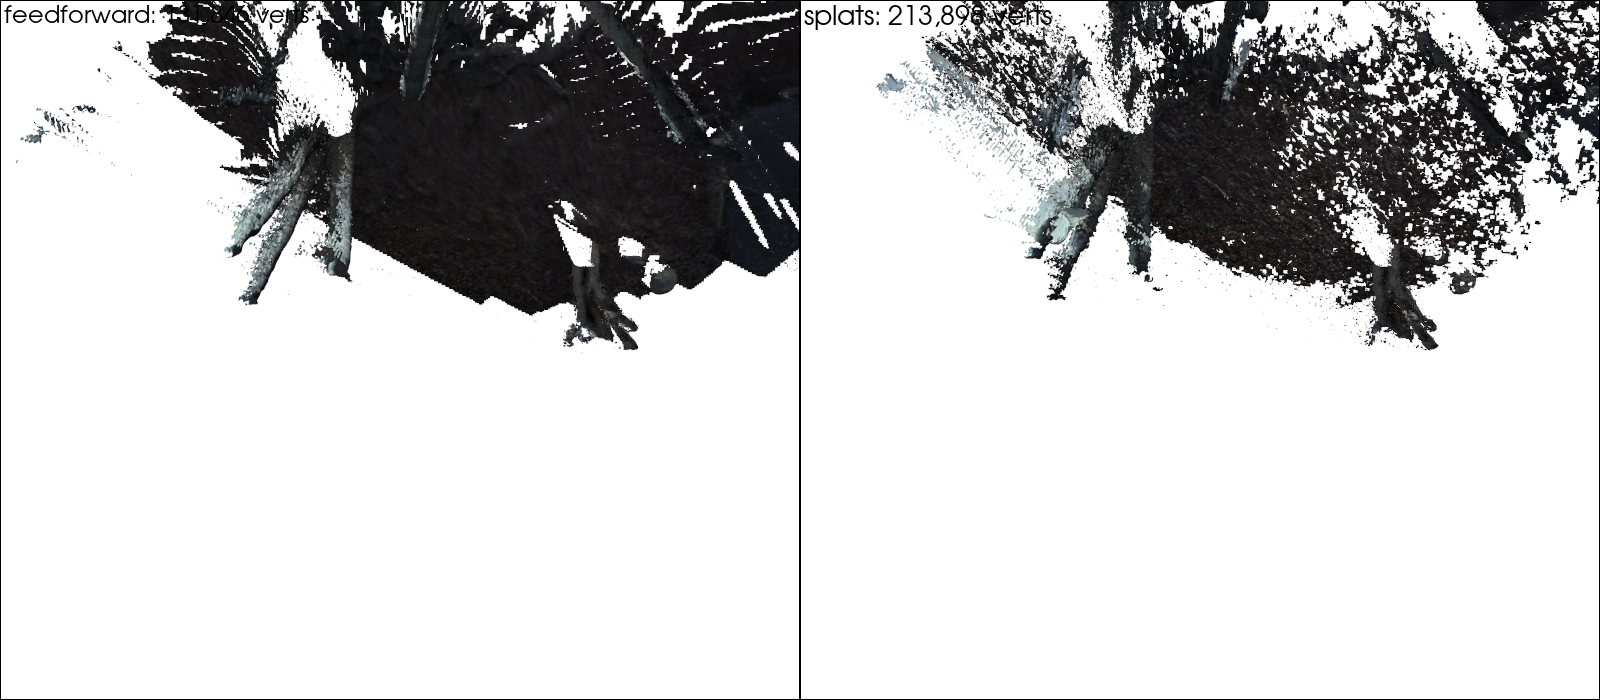

In [6]:
def mesh_to_polydata(mesh: o3d.geometry.TriangleMesh) -> pv.PolyData:
    # Open3D mesh -> PyVista PolyData with uint8 vertex colours
    vertices = np.asarray(mesh.vertices)
    triangles = np.asarray(mesh.triangles)
    faces = np.hstack([np.full((len(triangles), 1), 3), triangles]).ravel()
    poly = pv.PolyData(vertices, faces)
    poly["RGB"] = (np.asarray(mesh.vertex_colors) * 255).astype(np.uint8)
    return poly


def mesh_stats(mesh: o3d.geometry.TriangleMesh) -> dict:
    # Connected components over triangle adjacency
    cluster_ids, cluster_sizes, _ = mesh.cluster_connected_triangles()
    n_components = len(cluster_sizes)
    largest = int(max(cluster_sizes)) if n_components else 0
    return {
        "vertices": len(mesh.vertices),
        "triangles": len(mesh.triangles),
        "components": n_components,
        "largest_component_tris": largest,
    }


meshes = {
    "feedforward": o3d.io.read_triangle_mesh(str(mesh_ff.mesh_path)),
    "splats": o3d.io.read_triangle_mesh(str(mesh_sp.mesh_path)),
}
stats = {name: mesh_stats(mesh) for name, mesh in meshes.items()}

# Stats table
columns = list(next(iter(stats.values())).keys())
print(f"{'source':<12}" + "".join(f"{col:>24}" for col in columns))
for name, row in stats.items():
    print(f"{name:<12}" + "".join(f"{row[col]:>24,}" for col in columns))

# Side-by-side static render, shared camera
pl = pv.Plotter(shape=(1, 2), window_size=(1600, 700))
for col, (name, mesh) in enumerate(meshes.items()):
    pl.subplot(0, col)
    pl.add_mesh(mesh_to_polydata(mesh), scalars="RGB", rgb=True)
    pl.add_text(f"{name}: {stats[name]['vertices']:,} verts", font_size=12)
    pl.camera_position = [VIZ_KWARGS["position"], VIZ_KWARGS["focal_point"], VIZ_KWARGS["view_up"]]
    pl.camera.azimuth = VIZ_KWARGS["azimuth"]
    pl.camera.elevation = VIZ_KWARGS["elevation"]
    pl.camera.zoom(VIZ_KWARGS["zoom"])
pl.link_views()
pl.show()

## §4 — Pipeline equivalents

- `mesh.source: splats` in the config selects the §2 path inside `Reconstructor.mesh()`; `feedforward`
  (default) selects §1. Both read `mesh.voxel_size` / `sdf_trunc` / `depth_trunc` / `conf_percentile`.
- Against a processed scene: `--stages splats mesh` trains the splat, then meshes from its renders. The splats
  stage is never auto-run, so `mesh.source: splats` with no `splats.zarr` on disk raises.
- `mesh.native_resolution` is **ignored** on the splats path — the renders are already at frame resolution,
  so there is nothing to upsample. It only affects the feedforward path.
- The pipeline uses COLMAP poses (`colmap/sparse/0`) as the pose authority for the feedforward path; this
  notebook uses the zarr's extrinsics, which are identical unless BA or loop closure ran.

## §5 — Semantic query on the mesh

Replacement for the retired `Splatter.query_mesh`. One step per cell: lifted per-point features →
per-vertex features → text-query scores → painted mesh → largest matching cluster saved as `query_mesh.ply`.

**Step 1 — per-point features.** Same flow as `05_lifting/semantic_lifting.ipynb`: MaskCLIP on every
keyframe, a `FeatureAutoencoder` compressing to `LATENT_DIM`, `lift_features` onto `ff.points`. If nb 05
already wrote its cache under `TUTORIAL_CACHE/lifted/`, it is loaded instead.

In [7]:
# MaskCLIP from the registry — used for extraction here and for text scoring below
maskclip = BaseQueryableExtractor.get(EXTRACTOR)(device=DEVICE)

if LIFTED_MASKCLIP.exists() and AE_MASKCLIP.exists():
    # Cache hit: compressed codes + the AE that decodes them back to CLIP space
    ae = FeatureAutoencoder.load(AE_MASKCLIP).to(DEVICE)
    lifted_store = zarr.open_group(store=str(LIFTED_MASKCLIP), mode="r")
    compressed = torch.from_numpy(np.asarray(lifted_store["features"][:]))
    print(f"Loaded from cache: {compressed.shape} → {LIFTED_MASKCLIP}")
else:
    # Pixels come from the canonical frames.zarr — ff.image_paths point at a transient export dir
    frame_store = FrameStore.open(FRAMES_ZARR)
    images = [
        Image.fromarray(frame_store.image_by_frame_idx(FrameStore.frame_idx_from_path(path))).convert("RGB")
        for path in tqdm(ff.image_paths, desc="Loading frames")
    ]

    # Extract per-frame patch maps, fit a plain AE, compress, lift to the pointcloud
    feature_maps = maskclip.forward(images)  # list of (D, H_p, W_p)
    feature_dim = feature_maps[0].shape[0]
    ae = FeatureAutoencoder(feature_dim, LATENT_DIM).to(DEVICE)
    ae.fit(torch.cat([fmap.flatten(1).T for fmap in feature_maps]).to(DEVICE), epochs=100, target_cosine=0.95)
    compressed_maps = [ae.encode(fmap.to(DEVICE)).detach().cpu() for fmap in feature_maps]
    compressed = lift_features(compressed_maps, ff)  # (P, LATENT_DIM)

    # Persist in nb 05's layout so either notebook can reuse it
    lifted_store = zarr.open_group(store=str(LIFTED_MASKCLIP), mode="w")
    lifted_store.create_array(
        "features", data=compressed.numpy(), chunks=compressed.shape, compressors=BloscCodec(cname="lz4")
    )
    ae.save(AE_MASKCLIP)
    print(f"Saved: {compressed.shape} → {LIFTED_MASKCLIP}")

# Decode to full CLIP dimension — text scoring happens in the decoded space
point_feats = ae.per_point_decode(compressed.to(DEVICE)).detach().cpu().numpy()
print(f"point_feats: {point_feats.shape}")

Loading frames:   0%|          | 0/30 [00:00<?, ?it/s]

fit autoencoder:   0%|          | 0/100 [00:00<?, ?epoch/s]

Saved: torch.Size([500000, 13]) → /workspace/collab-splats-splats/data/outputs/tutorial_cache/lifted/lifted_maskclip.zarr


point_feats: (500000, 768)


**Step 2 — vertex features.** `features2vertex` maps point features onto the splats mesh by Gaussian-weighted
KNN (`k=5`); points farther than `sdf_trunc` from their nearest vertex are ignored.

In [8]:
# Per-vertex features on the splats-source mesh
query_mesh_src = meshes["splats"]
vertices = np.asarray(query_mesh_src.vertices)
vertex_feats = features2vertex(vertices, ff.points, point_feats, k=5, sdf_trunc=0.03)
print(f"vertex_feats: {vertex_feats.shape}")

vertex_feats: (213898, 768)


**Step 3 — scores.** `score_queries` is a contrastive softmax over positive vs negative queries, in `[0, 1]`.

In [9]:
# Contrastive text score per vertex
vertex_feats_dev = torch.from_numpy(vertex_feats).to(DEVICE)
scores = (
    maskclip.score_queries(vertex_feats_dev, positive=QUERY_POSITIVE, negative=QUERY_NEGATIVE, temperature=0.05)
    .detach()
    .cpu()
    .numpy()
)
n_above = int((scores > QUERY_THRESHOLD).sum())
print(f"scores: {scores.shape}  min={scores.min():.3f}  max={scores.max():.3f}  >{QUERY_THRESHOLD}: {n_above:,}")

scores: (213898,)  min=0.107  max=0.993  >0.6: 19,083


**Step 4 — paint.** The mesh coloured by score (viridis; yellow = matches `QUERY_POSITIVE`).

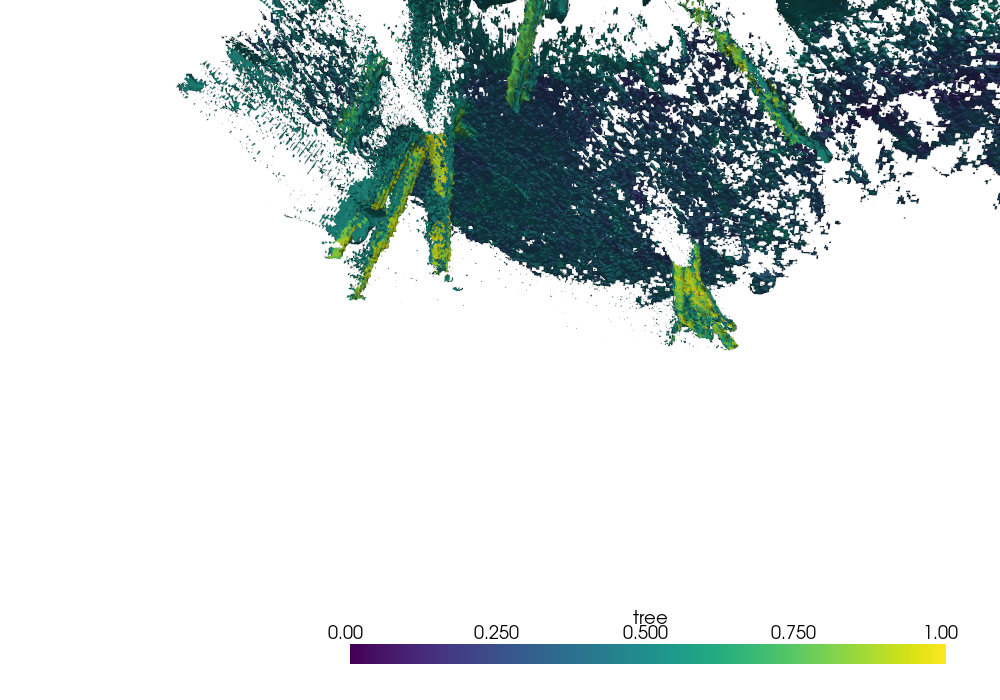

In [10]:
# Score-painted mesh, static render
painted = mesh_to_polydata(query_mesh_src)
painted["semantic"] = scores

pl = pv.Plotter(window_size=(1000, 700))
pl.add_mesh(painted, scalars="semantic", cmap="viridis", clim=(0.0, 1.0), scalar_bar_args={"title": " / ".join(QUERY_POSITIVE)})
pl.camera_position = [VIZ_KWARGS["position"], VIZ_KWARGS["focal_point"], VIZ_KWARGS["view_up"]]
pl.camera.azimuth = VIZ_KWARGS["azimuth"]
pl.camera.elevation = VIZ_KWARGS["elevation"]
pl.camera.zoom(VIZ_KWARGS["zoom"])
pl.show()

**Step 5 — cluster and save.** `mesh_clustering` keeps vertices above `QUERY_THRESHOLD`, connects them within
`spatial_radius`, and returns the connected components (≥ 10 vertices). The largest is cut out with
`select_by_index` and written as `query_mesh.ply` beside the splats mesh.

Building adjacency matrix: 0it [00:00, ?it/s]

7 clusters; largest has 10,452 vertices
query_mesh: 10,303 verts, 17,950 tris → /workspace/collab-splats-splats/data/outputs/tutorial_cache/mesh_splats/query_mesh.ply


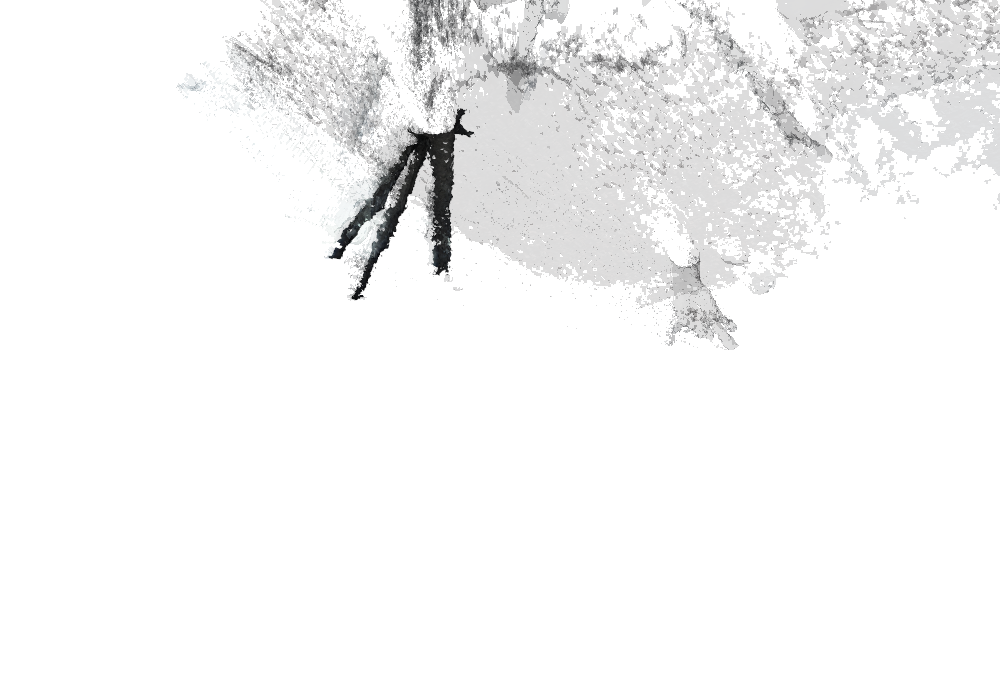

In [11]:
# Connected components over high-scoring vertices; keep the largest
clusters = mesh_clustering(query_mesh_src, scores, similarity_threshold=QUERY_THRESHOLD, spatial_radius=0.03)
assert clusters, f"no vertex cluster above {QUERY_THRESHOLD} for {QUERY_POSITIVE} — lower QUERY_THRESHOLD"
largest = max(clusters, key=len)
print(f"{len(clusters)} clusters; largest has {len(largest):,} vertices")

# Sub-mesh of the largest cluster, saved beside the splats mesh
query_mesh = query_mesh_src.select_by_index(largest.tolist())
query_mesh_path = MESH_SPLATS_DIR / "query_mesh.ply"
o3d.io.write_triangle_mesh(str(query_mesh_path), query_mesh)
print(f"query_mesh: {len(query_mesh.vertices):,} verts, {len(query_mesh.triangles):,} tris → {query_mesh_path}")

pl = pv.Plotter(window_size=(1000, 700))
pl.add_mesh(mesh_to_polydata(query_mesh_src), scalars="RGB", rgb=True, opacity=0.15)
pl.add_mesh(mesh_to_polydata(query_mesh), scalars="RGB", rgb=True)
pl.camera_position = [VIZ_KWARGS["position"], VIZ_KWARGS["focal_point"], VIZ_KWARGS["view_up"]]
pl.camera.azimuth = VIZ_KWARGS["azimuth"]
pl.camera.elevation = VIZ_KWARGS["elevation"]
pl.camera.zoom(VIZ_KWARGS["zoom"])
pl.show()